In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.defaule = 'colab'

from itables import show

# This stops a few warning messages from showing
pd.options.mode.chained_assignment = None 
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Machine Learning Packages
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression 

In [2]:
DF_raw = pd.read_csv('2019.csv')
DF = pd.read_csv('2019.csv')
DF

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298
...,...,...,...,...,...,...,...,...,...
151,152,Rwanda,3.334,0.359,0.711,0.614,0.555,0.217,0.411
152,153,Tanzania,3.231,0.476,0.885,0.499,0.417,0.276,0.147
153,154,Afghanistan,3.203,0.350,0.517,0.361,0.000,0.158,0.025
154,155,Central African Republic,3.083,0.026,0.000,0.105,0.225,0.235,0.035


In [3]:
DF.describe()

,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


In [4]:
DF.shape

(156, 9)

In [5]:
DF['GDP per capita'].value_counts

<bound method IndexOpsMixin.value_counts of 0      1.340
1      1.383
2      1.488
3      1.380
4      1.396
       ...  
151    0.359
152    0.476
153    0.350
154    0.026
155    0.306
Name: GDP per capita, Length: 156, dtype: float64>

In [6]:
DF['GDP per capita'].idxmax()

28

In [7]:
max_country = DF.loc[DF['GDP per capita'].idxmax(), 'Country or region']
max_value = DF['GDP per capita'].max()

print(max_country, max_value)

Qatar 1.684


highest GDP Qatar: 1.684

In [8]:
DF['GDP per capita'].idxmin()

111

In [9]:
max_country = DF.loc[DF['GDP per capita'].idxmin(), 'Country or region']
max_value = DF['GDP per capita'].min()

print(max_country, max_value)

Somalia 0.0


lowest GDP Somalia:

In [10]:
max_country = DF.loc[DF['Score'].idxmax(), 'Country or region']
max_value = DF['Score'].max()

print(max_country, max_value)

Finland 7.769


In [11]:
max_country = DF.loc[DF['Score'].idxmin(), 'Country or region']
max_value = DF['Score'].min()

print(max_country, max_value)

South Sudan 2.853


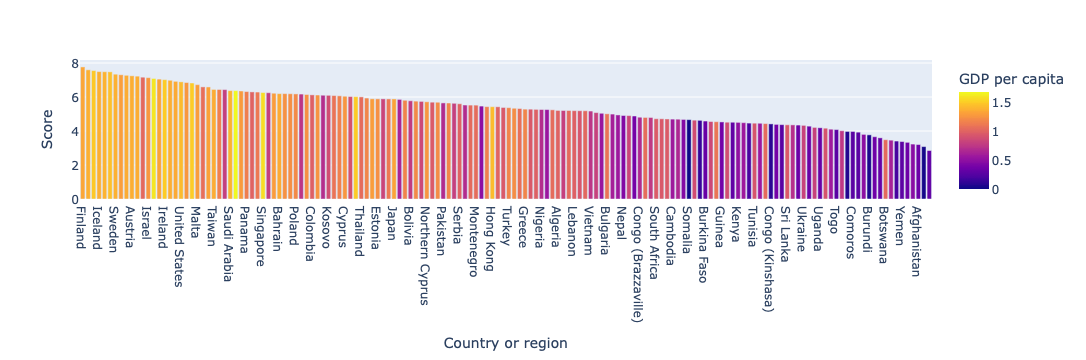

In [38]:
px.bar(DF, x='Country or region', y='Score',
      color='GDP per capita')

This visual right off the bat shows a correlation between the happiest countries having a higher GDP per capita. 



In [45]:
DF3_raw = pd.read_csv('gdp_per_capita.csv')
DF3 = pd.read_csv('gdp_per_capita.csv')
DF3

,Country Name,Code,1960,1961,1962,1963,1964,1965,1966,1967,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,Unnamed: 65
0,Aruba,ABW,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,24712.493263,26441.619936,26893.011506,28396.908423,28452.170615,29350.805019,30253.279358,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,147.612227,147.014904,156.189192,182.243917,162.347592,180.214908,190.845484,192.337167,...,1736.166560,1713.899299,1703.596298,1549.037940,1431.778723,1573.063386,1574.978648,1530.059177,1359.618224,NaN
2,Afghanistan,AFG,59.773234,59.860900,58.458009,78.706429,82.095307,101.108325,137.594298,160.898434,...,638.845852,624.315455,614.223342,556.007221,512.012778,516.679862,485.668419,494.179350,516.747871,NaN
3,Africa Western and Central,AFW,107.932233,113.081647,118.831107,123.442888,131.854402,138.526332,144.326212,128.582470,...,1965.118485,2157.481149,2212.853135,1894.310195,1673.835527,1613.473553,1704.139603,1777.918672,1710.073363,NaN
4,Angola,AGO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5100.097027,5254.881126,5408.411700,4166.979833,3506.073128,4095.810057,3289.643995,2809.626088,1776.166868,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3410.859780,3704.784221,3902.676013,3520.766449,3759.560246,4009.380987,4384.048892,4416.108358,4346.637931,NaN
262,"Yemen, Rep.",YEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1446.536472,1607.152173,1674.002572,1601.830063,1152.720966,964.264811,758.145242,NaN,NaN,NaN
263,South Africa,ZAF,443.009920,454.962013,473.011405,511.497364,548.996058,584.704163,621.220543,675.135345,...,8222.197279,7467.079185,6988.808739,6259.839681,5756.965741,6690.939847,7005.095413,6624.761865,5655.867654,NaN
264,Zambia,ZMB,232.188564,220.042067,212.578449,213.896759,242.384473,303.281740,343.373670,360.201239,...,1763.069442,1878.346811,1762.427817,1338.290927,1280.806543,1535.196574,1516.368371,1305.001031,985.132436,NaN


In [46]:
GDPpc = ['Country Name','2020']
DF3_GDPpc = DF3[GDPpc]
show(DF3_GDPpc)

Loading ITables v2.5.2 from the internet... (need help?)


In [47]:
DF3_GDPpc_sorted = DF3_GDPpc.sort_values(by='2020', ascending=False)
DF3_GDPpc_sorted

,Country Name,2020
149,Monaco,173688.189360
144,Luxembourg,116014.602497
27,Bermuda,107079.479837
37,Switzerland,87097.036450
111,Ireland,85267.764744
...,...,...
235,Turkmenistan,NaN
254,"Venezuela, RB",NaN
255,British Virgin Islands,NaN
256,Virgin Islands (U.S.),NaN


In [48]:
DF3_GDPpc = DF3_GDPpc.rename(columns={'2020':'GDPpc'})
DF3_GDPpc = DF3_GDPpc.rename(columns={'Country Name':'Country or region'})
DF3_GDPpc

,Country or region,GDPpc
0,Aruba,NaN
1,Africa Eastern and Southern,1359.618224
2,Afghanistan,516.747871
3,Africa Western and Central,1710.073363
4,Angola,1776.166868
...,...,...
261,Kosovo,4346.637931
262,"Yemen, Rep.",NaN
263,South Africa,5655.867654
264,Zambia,985.132436


In [49]:
DF3_GDPpc = pd.merge(DF3_GDPpc,DF,on='Country or region',how='inner')
DF3_GDPpc

,Country or region,GDPpc,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,Afghanistan,516.747871,154,3.203,0.350,0.517,0.361,0.000,0.158,0.025
1,Albania,5246.292306,107,4.719,0.947,0.848,0.874,0.383,0.178,0.027
2,United Arab Emirates,36284.555243,21,6.825,1.503,1.310,0.825,0.598,0.262,0.182
3,Argentina,8579.017773,47,6.086,1.092,1.432,0.881,0.471,0.066,0.050
4,Armenia,4266.018074,116,4.559,0.850,1.055,0.815,0.283,0.095,0.064
...,...,...,...,...,...,...,...,...,...,...
131,Vietnam,2785.724161,94,5.175,0.741,1.346,0.851,0.543,0.147,0.073
132,Kosovo,4346.637931,46,6.100,0.882,1.232,0.758,0.489,0.262,0.006
133,South Africa,5655.867654,106,4.722,0.960,1.351,0.469,0.389,0.130,0.055
134,Zambia,985.132436,138,4.107,0.578,1.058,0.426,0.431,0.247,0.087


In [50]:
GDPpc_ = ['Country or region','GDPpc','Score']
DF_new = DF3_GDPpc[GDPpc_]
show(DF_new)

Loading ITables v2.5.2 from the internet... (need help?)


In [51]:
my_columns = ['GDPpc','Score']
DF_model = DF_new[my_columns].copy()

print('Number of NaNs:')
print(DF_model.isna().sum())
print('----------------------')

print('Percent total NaNs:')
print(DF_model.isna().sum().sum()/len(DF))
print('----------------------')

DF_model.dropna(inplace=True)
print('Number of NaNs after drop:')
print(DF_model.isna().sum().sum())
print('----------------------')

Number of NaNs:
GDPpc    2
Score    0
dtype: int64
----------------------
Percent total NaNs:
0.01282051282051282
----------------------
Number of NaNs after drop:
0
----------------------


In [52]:
X = DF_model['Score'].values.reshape(-1, 1)
y = DF_model['GDPpc'].values
LM = LinearRegression()

LM.fit(X, y)

LinearRegression()

In [53]:
my_cols = ['GDPpc', 'Score']
DF_new[my_cols].dtypes

GDPpc    float64
Score    float64
dtype: object

In [54]:
print(LM.coef_)
print(LM.intercept_)

print(LM.score(X,y))

[13822.16007263]
-60716.043042505116
0.5361608808203893


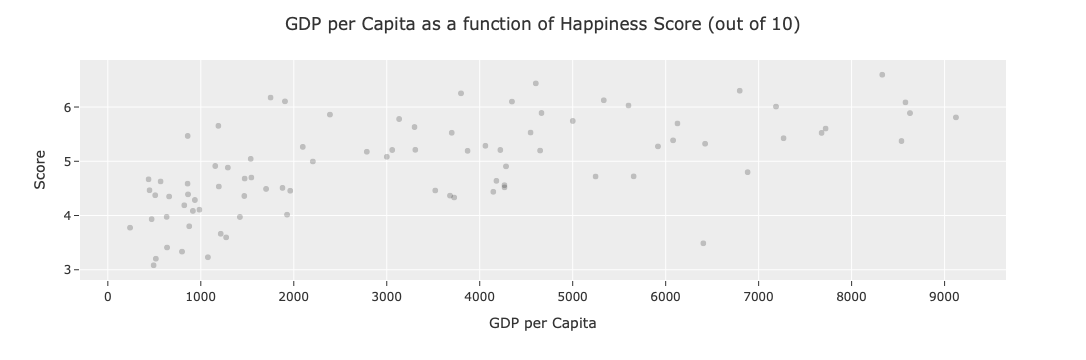

Model Score:
0.3759503631896627


In [55]:
my_columns = ['GDPpc','Score']
DF_model2 = DF_new[my_columns]

DF_model2.dropna(inplace=True)
DF_model2['GDPpc'] = DF_model2['GDPpc'].apply(lambda x: float(x))

mask = DF_model2['GDPpc'] <= 10_000
DF_model2 = DF_model2[mask]

fig = px.scatter(DF_model2,
                 x='GDPpc',
                 y='Score',
                 color_discrete_sequence=['black'],
                 opacity=0.2)

fig.update_layout(template="ggplot2",
                  title='GDP per Capita as a function of Happiness Score (out of 10)',
                  title_x=0.5,
                  xaxis_title='GDP per Capita',
                  yaxis_title='Score')


fig.show()

X = DF_model2['GDPpc'].values.reshape(-1,1)
y = DF_model2['Score'].values

LM = LinearRegression()
LM.fit(X, y)

print('Model Score:')
print(LM.score(X,y))

With an R^2 of 0.37, GDP per capita explains about 37% of the differences in happiness levels between countries. This is a moderate relationship that shows that wealth contributes to happiness, but there are definetly other factors where most of the variation comes from other social, cultural, and political factors.

Diminishing returns to income

Economic theory suggests that diminishing returns to income exist, meaning that as income increases, happiness increases, but the size of that increase becomes smaller as income grows. For low income countries, small increases in GDP per capita leads to great improvements in quality of life. On the other hand, when countries of higher economic developement get increases in GDP per capita, addittional income leads to a smaller increase in happiness, since essential needs have already been met. This means that as the income increases, each additional dollar gives you less extra happiness than the dollar before it. Raw GDP per capita treats every dollar increase as equally meaningful, and therefore the relationship between income and happiness may appear questionable when modeled directly.

In [56]:
DF_model2['log_GDPpc'] = np.log(DF_model2['GDPpc'])

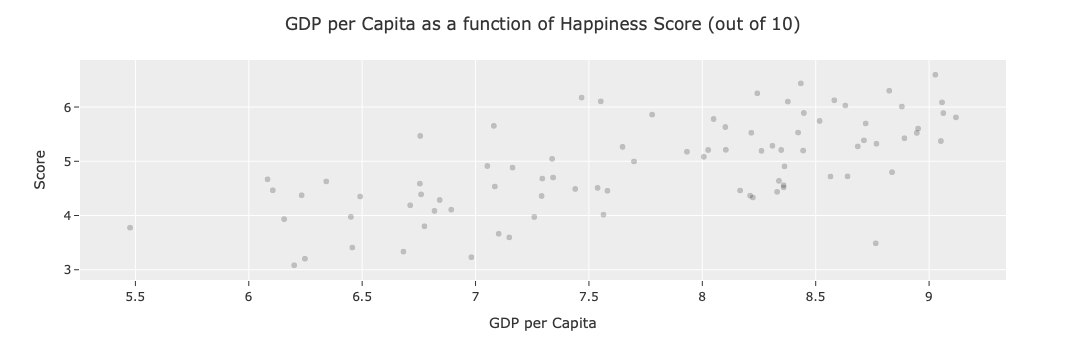

Model Score:
0.43053729417078024


In [57]:
DF_model2.dropna(inplace=True)
DF_model2['log_GDPpc'] = DF_model2['log_GDPpc'].apply(lambda x: float(x))

mask = DF_model2['log_GDPpc'] <= 10_000
DF_model2 = DF_model2[mask]

fig = px.scatter(DF_model2,
                 x='log_GDPpc',
                 y='Score',
                 color_discrete_sequence=['black'],
                 opacity=0.2)

fig.update_layout(template="ggplot2",
                  title='GDP per Capita as a function of Happiness Score (out of 10)',
                  title_x=0.5,
                  xaxis_title='GDP per Capita',
                  yaxis_title='Score')


fig.show()

X = DF_model2['log_GDPpc'].values.reshape(-1,1)
y = DF_model2['Score'].values

LM = LinearRegression()
LM.fit(X, y)

print('Model Score:')
print(LM.score(X,y))

I applied a logarithm to GDP per capita to better capture the diminishing returns pattern. By doing this, it converts the income differences into percentage differences, aligning more closely with how income influences happiness in real world settings. A percentage increase if far more meaningful in a poor coutry vs. a wealthy country. After taking the log, the relationship between GDP per capita and the happiness score became more linear, with the R^2 score increasing from a .37 to .43. this improvement directly reflects how happiness increases less and less as countries get richer. The log of Gdp per capita provides a better and more realistic representation of the relationship with happiness than the raw GDP per capita values do.



Overall, I was trying to determine if GDP per capita is related to happiness, and it does but it does not fully determine it. Countries with higher incomes tend to have higher happiness scores, but it is not a perfect relationship. The improvement of variation in happiness supports the economic theory of diminishing returns, but other factors beyond economic recourses play a substantial role in shaping a nation's happiness.